# Data Cleaning – Version 1

This notebook prepares the initial cleaned dataset for the ride cancellation prediction project.

Main tasks:
- load the raw dataset
- filter relevant booking statuses
- create a binary target variable
- remove identifier and leakage-prone columns
- check missing values and duplicates
- save the cleaned dataset

## Step 1: Load the cleaned dataset
In this step, the cleaned dataset is uploaded and loaded into Python for exploratory data analysis.

In [ ]:
import pandas as pd

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving model_ready_v1.csv to model_ready_v1.csv


In [ ]:
uploaded.keys()

dict_keys(['model_ready_v1.csv'])

In [ ]:
eda_df = pd.read_csv("model_ready_v1.csv")

## Step 2: Inspect the cleaned dataset
In this step, the cleaned dataset is displayed and checked to confirm that it has been loaded correctly and is ready for exploratory analysis.

In [ ]:
eda_df.head()

,Date,Time,Booking Status,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,target_cancelled
0,8/23/2024,8:56:10,Completed,Auto,Khandsa,Malviya Nagar,13.4,0
1,10/21/2024,17:17:25,Completed,Premier Sedan,Central Secretariat,Inderlok,13.1,0
2,9/16/2024,22:08:00,Completed,Bike,Ghitorni Village,Khan Market,5.3,0
3,2/6/2024,9:44:56,Completed,Auto,AIIMS,Narsinghpur,5.1,0
4,6/17/2024,15:45:58,Completed,Go Mini,Vaishali,Punjabi Bagh,7.1,0


## Step 3: Check the dataset size and structure
In this step, the size of the cleaned dataset and its column structure are examined to understand the scope of the exploratory analysis.

In [ ]:
eda_df.shape

(130500, 8)

In [ ]:
eda_df.columns

Index(['Date', 'Time', 'Booking Status', 'Vehicle Type', 'Pickup Location',
       'Drop Location', 'Avg VTAT', 'target_cancelled'],
      dtype='object')

## Examine the target distribution
This step checks the distribution of cancelled and non-cancelled bookings in the cleaned dataset. This is important for understanding the class balance and the overall scale of the cancellation problem.

In [ ]:
eda_df["target_cancelled"].value_counts()

,count
target_cancelled,
0,93000
1,37500


In [ ]:
eda_df["target_cancelled"].value_counts(normalize=True) * 100

,proportion
target_cancelled,
0,71.264368
1,28.735632


In [ ]:
eda_df['Time'] = pd.to_datetime(eda_df['Time'], format='%H:%M:%S', errors='coerce')

In [ ]:
eda_df['hour'] = eda_df['Time'].dt.hour

In [ ]:
eda_df[['Time', 'hour']].head()

,Time,hour
0,1900-01-01 08:56:10,8
1,1900-01-01 17:17:25,17
2,1900-01-01 22:08:00,22
3,1900-01-01 09:44:56,9
4,1900-01-01 15:45:58,15


### Hour of Day vs Cancellation

This analysis explores how the time of day (hour) affects ride cancellations.  
Time is an important operational factor, as cancellation behavior may vary during peak hours, early mornings, or late-night periods.

The objective is to identify time periods with higher cancellation rates.

In [ ]:
hourly_cancel = pd.crosstab(
    eda_df['hour'],
    eda_df['target_cancelled'],
    normalize='index'
)

hourly_cancel

target_cancelled,0,1
hour,,
0,0.716194,0.283806
1,0.706485,0.293515
2,0.741739,0.258261
3,0.707819,0.292181
4,0.710616,0.289384
5,0.699714,0.300286
6,0.721915,0.278085
7,0.707699,0.292301
8,0.713426,0.286574


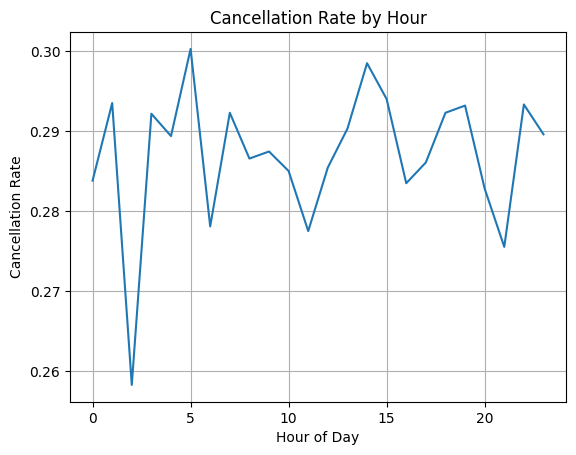

In [ ]:
import matplotlib.pyplot as plt

hourly_cancel[1].plot(kind='line')

plt.title('Cancellation Rate by Hour')
plt.ylabel('Cancellation Rate')
plt.xlabel('Hour of Day')
plt.grid(True)
plt.show()

### Vehicle Type vs Cancellation

This analysis examines whether the type of vehicle influences ride cancellation rates.  
Different vehicle categories may reflect variations in pricing, availability, and customer preferences.

The objective is to assess whether certain vehicle types are associated with higher cancellation likelihood.

In [ ]:
vehicle_cancel = pd.crosstab(
    eda_df['Vehicle Type'],
    eda_df['target_cancelled'],
    normalize='index'
)

vehicle_cancel

target_cancelled,0,1
Vehicle Type,,
Auto,0.712944,0.287056
Bike,0.712892,0.287108
Go Mini,0.714082,0.285918
Go Sedan,0.708441,0.291559
Premier Sedan,0.713597,0.286403
Uber XL,0.718750,0.281250
eBike,0.713539,0.286461


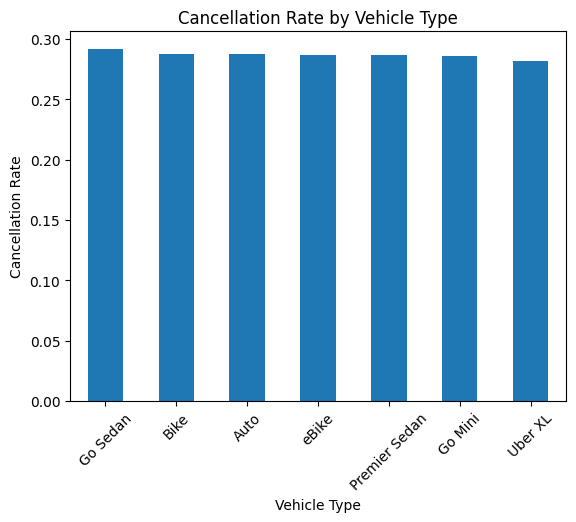

In [ ]:
vehicle_cancel[1].sort_values(ascending=False).plot(kind='bar')

plt.title('Cancellation Rate by Vehicle Type')
plt.ylabel('Cancellation Rate')
plt.xlabel('Vehicle Type')
plt.xticks(rotation=45)
plt.show()

### Pickup Location vs Cancellation

This analysis examines whether the pickup location affects the likelihood of ride cancellations.  
Location is expected to be an important factor because it may reflect traffic conditions, demand-supply imbalance, and driver availability.

The goal is to identify locations with higher cancellation rates.

In [ ]:
pickup_cancel = pd.crosstab(
    eda_df['Pickup Location'],
    eda_df['target_cancelled'],
    normalize='index'
)

pickup_cancel.sort_values(by=1, ascending=False).head(10)

target_cancelled,0,1
Pickup Location,,
Vinobapuri,0.648415,0.351585
Akshardham,0.655076,0.344924
Faridabad Sector 15,0.676838,0.323162
Munirka,0.676880,0.323120
Chhatarpur,0.678873,0.321127
Qutub Minar,0.680384,0.319616
GTB Nagar,0.682415,0.317585
Badshahpur,0.682861,0.317139
Netaji Subhash Place,0.683029,0.316971


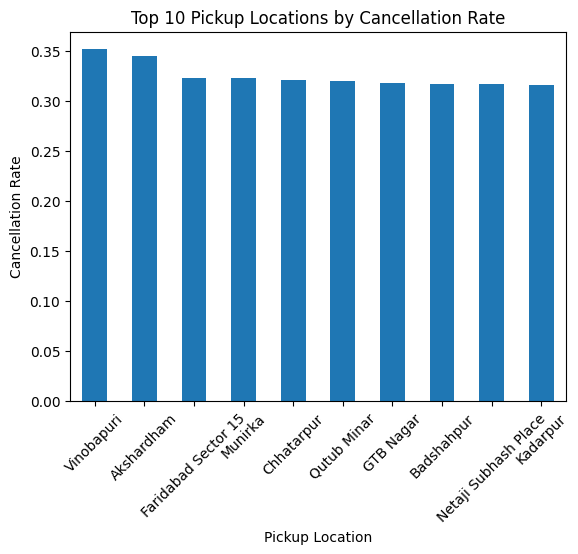

In [ ]:
pickup_cancel.sort_values(by=1, ascending=False).head(10)[1].plot(kind='bar')

plt.title('Top 10 Pickup Locations by Cancellation Rate')
plt.ylabel('Cancellation Rate')
plt.xlabel('Pickup Location')
plt.xticks(rotation=45)
plt.show()

### Key Insight from Pickup Location

The analysis shows that cancellation rates vary significantly across pickup locations.  
Certain areas such as Vinobapuri and Akshardham exhibit notably higher cancellation rates compared to others.

This suggests that location is a strong predictor of ride cancellations, potentially due to factors such as traffic conditions, driver availability, and demand-supply imbalance.

Therefore, pickup location is expected to be an important feature in the predictive model.

### Avg VTAT vs Cancellation

This analysis examines how driver waiting time (VTAT) affects ride cancellations.  
Longer waiting times are expected to increase the likelihood of cancellations, as customers may lose patience or seek alternative options.

The goal is to assess whether higher VTAT values are associated with higher cancellation rates.

In [ ]:
eda_df.groupby('target_cancelled')['Avg VTAT'].mean()

,Avg VTAT
target_cancelled,
0,8.511878
1,8.904872


### Avg VTAT Distribution by Cancellation

This analysis compares the distribution of driver waiting time (VTAT) between cancelled and completed rides.  
The aim is to visually assess whether higher waiting times are associated with increased cancellations.

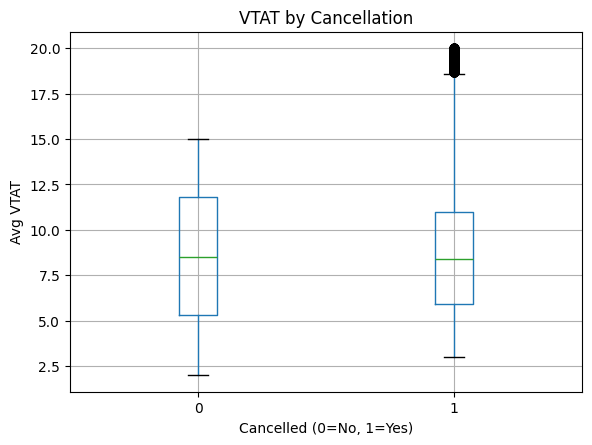

In [ ]:
import matplotlib.pyplot as plt

eda_df.boxplot(column='Avg VTAT', by='target_cancelled')

plt.title('VTAT by Cancellation')
plt.suptitle('')
plt.xlabel('Cancelled (0=No, 1=Yes)')
plt.ylabel('Avg VTAT')
plt.show()

### Key Insight from VTAT

The analysis indicates that rides with higher driver waiting times (VTAT) are more likely to be cancelled.  
Both the average values and the distribution show that cancelled rides tend to have higher waiting times compared to completed rides.

This suggests that waiting time is a strong driver of ride cancellations, as longer delays may lead to customer dissatisfaction and abandonment.

Therefore, Avg VTAT is expected to be one of the most important predictive features in the model.

## Modelling

### Preparing Data for Modelling

In this step, the dataset is prepared for machine learning by selecting relevant features and separating the target variable.

The goal is to define the input features (X) and the target variable (y).

In [ ]:
X = eda_df[['hour', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT']]

y = eda_df['target_cancelled']

### Encoding Categorical Variables

Machine learning models cannot work with categorical variables directly.  
Therefore, categorical features such as Vehicle Type, Pickup Location, and Drop Location must be converted into numerical format.

In this step, one-hot encoding is applied to transform categorical variables into dummy variables.

In [ ]:
X_encoded = pd.get_dummies(X, drop_first=True)

### Train-Test Split

To evaluate the model properly and avoid overfitting, the dataset is split into training and testing sets.

The model will be trained on the training set and evaluated on unseen test data.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

### Logistic Regression Model

In this step, a Logistic Regression model is trained as a baseline model for predicting ride cancellations.

This model is simple, interpretable, and provides a good starting point for evaluating performance.

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

### Model Evaluation

In this step, the trained model is evaluated using the test dataset.  
Predictions are generated and key evaluation metrics such as accuracy, precision, recall, and F1-score are calculated.

This helps assess how well the model performs on unseen data.

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      1.00      0.83     18513
           1       0.00      0.00      0.00      7587

    accuracy                           0.71     26100
   macro avg       0.35      0.50      0.41     26100
weighted avg       0.50      0.71      0.59     26100



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Model Performance Insight

The Logistic Regression model achieved an overall accuracy of approximately 71%.  
However, the model completely failed to predict the cancelled rides (class 1), with zero recall and F1-score for this class.

This indicates that the model is biased towards the majority class (completed rides) due to class imbalance in the dataset.

Therefore, accuracy alone is misleading, and the model requires improvement to better capture cancellation cases.

### Improving the Model with Class Weights

The baseline Logistic Regression model failed to detect cancelled rides because of class imbalance.

To address this issue, class weights are introduced so that the model gives more importance to the minority class (cancelled rides).

In [ ]:
model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')

model_balanced.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
y_pred_balanced = model_balanced.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.71      0.53      0.61     18513
           1       0.30      0.48      0.37      7587

    accuracy                           0.51     26100
   macro avg       0.50      0.51      0.49     26100
weighted avg       0.59      0.51      0.54     26100



### Improved Model Performance

After applying class weights, the model is able to detect cancelled rides more effectively.  
The recall for the cancelled class (class 1) improved significantly from 0.00 to approximately 0.48.

Although the overall accuracy decreased, this is expected because the model is now less biased towards the majority class.

This demonstrates that handling class imbalance improves the model's ability to identify cancellation cases, which is more important for the business problem.

### Feature Importance (Logistic Regression)

In Logistic Regression, feature importance can be interpreted using the model coefficients.  
Higher absolute values indicate stronger influence on the prediction.

This helps identify which factors contribute most to ride cancellations.

In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': model_balanced.coef_[0]
})

feature_importance = feature_importance.sort_values(by='importance', ascending=False)

feature_importance.head(10)

,feature,importance
179,Pickup Location_Vinobapuri,0.334897
351,Drop Location_Vasant Kunj,0.324892
9,Pickup Location_Akshardham,0.323399
228,Drop Location_Gurgaon Sector 29,0.262667
200,Drop Location_Bhikaji Cama Place,0.259544
223,Drop Location_Govindpuri,0.230887
108,Pickup Location_Munirka,0.228683
218,Drop Location_GTB Nagar,0.219478
21,Pickup Location_Badshahpur,0.204218
353,Drop Location_Vidhan Sabha,0.193393


### Feature Importance Visualization

The top features influencing ride cancellations are visualized to better understand their relative impact.

This provides a clear interpretation of which variables most strongly affect the model predictions.

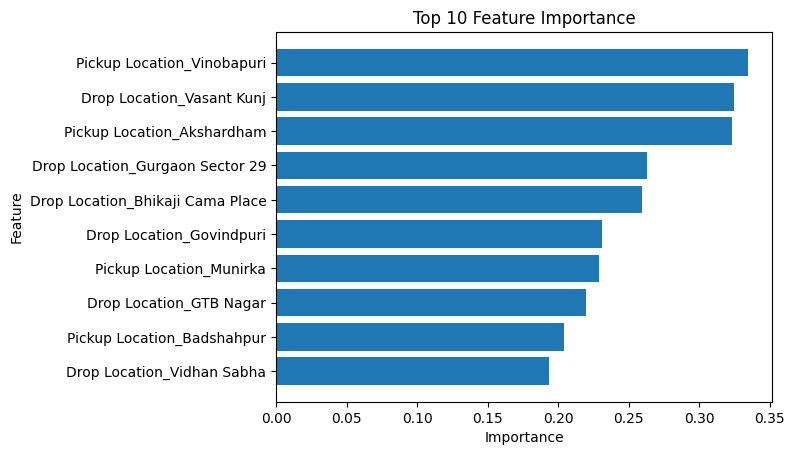

In [ ]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure()
plt.barh(top_features['feature'], top_features['importance'])

plt.title('Top 10 Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.gca().invert_yaxis()

plt.show()

### Confusion Matrix

The confusion matrix is used to evaluate the performance of the classification model by showing the number of correct and incorrect predictions for each class.

It provides a more detailed view of model performance compared to accuracy alone.

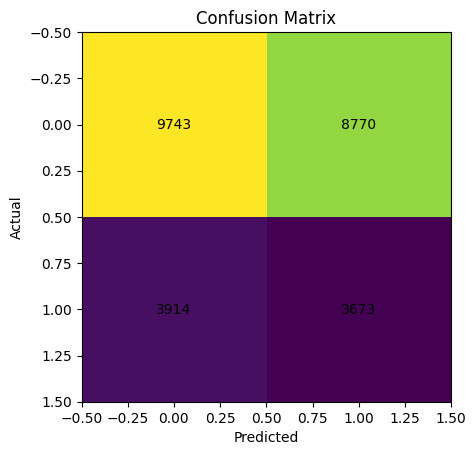

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_balanced)

plt.figure()
plt.imshow(cm)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

### Confusion Matrix Insight

The confusion matrix shows that the model is able to correctly identify a significant number of cancelled rides.

However, it also produces a high number of false positives, predicting cancellations for rides that were actually completed.

This indicates a trade-off between detecting cancellations and maintaining prediction accuracy.

From a business perspective, this trade-off may be acceptable if the goal is to minimize missed cancellations.

### ROC Curve and AUC

The ROC curve is used to evaluate the model's ability to distinguish between classes.

The AUC (Area Under Curve) provides a single metric summarizing the model's performance.

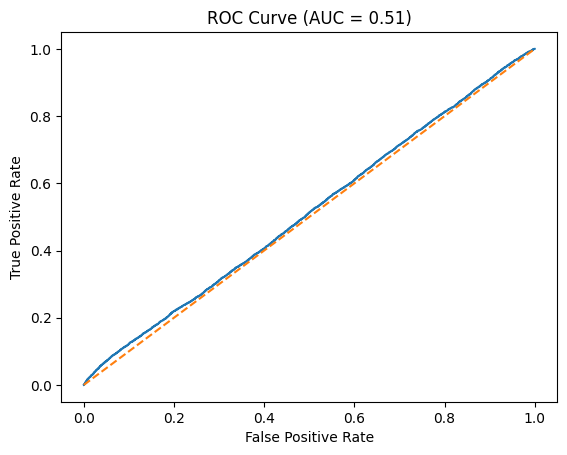

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model_balanced.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

import matplotlib.pyplot as plt

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')

plt.title(f'ROC Curve (AUC = {auc_score:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()

### ROC Curve Insight

The ROC curve shows that the model has an AUC score of approximately 0.51, which is very close to random guessing.

This indicates that the model has very limited ability to distinguish between cancelled and completed rides.

Despite improvements from handling class imbalance, the model still struggles to capture meaningful patterns in the data.

This suggests that additional feature engineering or more advanced models may be required to improve performance.

### Random Forest Model

In this step, a Random Forest model is used to improve prediction performance.

Random Forest is a more advanced model that can capture non-linear relationships and interactions between features, which may not be captured by Logistic Regression.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### Random Forest Model Evaluation

The Random Forest model is evaluated using the test dataset to assess its predictive performance.

The results are compared with the Logistic Regression model to determine whether performance has improved.

In [ ]:
y_pred_rf = rf_model.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.73      0.97      0.84     18513
           1       0.66      0.14      0.22      7587

    accuracy                           0.73     26100
   macro avg       0.69      0.55      0.53     26100
weighted avg       0.71      0.73      0.66     26100



### Random Forest Model Interpretation

The model performs very well in predicting non-cancelled rides, with a recall of 0.97.

However, its performance on cancelled rides is still weak, with a recall of only 0.14.

This means that the model fails to identify a large portion of actual cancellations.

The confusion matrix further confirms this issue, showing a high number of false negatives for the cancelled class.

Although Random Forest improves over Logistic Regression, the model is still biased toward the majority class.

This indicates that additional feature engineering, resampling techniques, or further tuning is required to improve detection of cancellations.

In [ ]:
!pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [ ]:
print(y_train.value_counts())
print(y_train_sm.value_counts())

target_cancelled
0    74487
1    29913
Name: count, dtype: int64
target_cancelled
0    74487
1    74487
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_smote = RandomForestClassifier(random_state=42)

rf_smote.fit(X_train_sm, y_train_sm)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_smote = rf_smote.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.74      0.89      0.81     18513
           1       0.46      0.23      0.30      7587

    accuracy                           0.70     26100
   macro avg       0.60      0.56      0.56     26100
weighted avg       0.66      0.70      0.66     26100



### Impact of SMOTE on Model Performance

After applying SMOTE, the model shows improved performance in detecting cancelled rides.

The recall for the cancelled class increased from 0.14 to 0.23, indicating that the model is now able to capture more cancellation cases.

This improvement comes at the cost of a slight decrease in performance for the non-cancelled class.

However, this trade-off is acceptable since the primary goal of the model is to identify cancellations more effectively.

Overall, SMOTE helps reduce the bias toward the majority class and improves model balance.

### XGBoost Model Improvement

To further improve prediction performance, an XGBoost model was applied.

XGBoost is a powerful boosting algorithm that can capture complex patterns and interactions between features.

Compared to previous models, XGBoost shows improved performance in detecting cancelled rides, especially in terms of recall.

This indicates that more advanced models are better suited for this problem.

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

In [ ]:
xgb_model.fit(X_train_sm, y_train_sm)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:03:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.79      0.57      0.67     18513
           1       0.38      0.63      0.47      7587

    accuracy                           0.59     26100
   macro avg       0.58      0.60      0.57     26100
weighted avg       0.67      0.59      0.61     26100



### Final Model Insight (XGBoost)

The XGBoost model significantly improves the detection of cancelled rides compared to previous models.

The recall for the cancelled class increased to 0.63, indicating that the model can now correctly identify a majority of cancellation cases.

Although the performance on non-cancelled rides decreased slightly, this trade-off is acceptable given the primary objective of capturing cancellations.

Overall, XGBoost provides the best balance between performance and practical usefulness, making it the most effective model in this project.

### Adjusting the Decision Threshold

By default, the model predicts a cancellation only when the predicted probability is above 0.5.

To improve the detection of cancelled rides, the decision threshold is reduced to 0.3.

This helps increase recall for the cancelled class, although it may reduce precision.

In [ ]:
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

y_pred_xgb_03 = (y_prob_xgb >= 0.30).astype(int)

### Evaluating Model with Adjusted Threshold

After lowering the threshold to 0.3, the model is expected to capture more cancelled rides.

This step evaluates whether recall for the cancelled class has improved.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb_03))

              precision    recall  f1-score   support

           0       0.92      0.30      0.45     18513
           1       0.36      0.94      0.52      7587

    accuracy                           0.49     26100
   macro avg       0.64      0.62      0.49     26100
weighted avg       0.76      0.49      0.47     26100



In [ ]:
import numpy as np

thresholds = np.arange(0.1, 0.6, 0.05)

for t in thresholds:
    y_pred_temp = (y_prob_xgb >= t).astype(int)
    from sklearn.metrics import recall_score
    recall = recall_score(y_test, y_pred_temp)
    print(f"Threshold: {t:.2f} → Recall: {recall:.3f}")

Threshold: 0.10 → Recall: 1.000
Threshold: 0.15 → Recall: 0.987
Threshold: 0.20 → Recall: 0.959
Threshold: 0.25 → Recall: 0.946
Threshold: 0.30 → Recall: 0.940
Threshold: 0.35 → Recall: 0.935
Threshold: 0.40 → Recall: 0.924
Threshold: 0.45 → Recall: 0.871
Threshold: 0.50 → Recall: 0.630
Threshold: 0.55 → Recall: 0.319


In [ ]:
y_pred_final = (y_prob_xgb >= 0.25).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.93      0.29      0.44     18513
           1       0.35      0.95      0.51      7587

    accuracy                           0.48     26100
   macro avg       0.64      0.62      0.48     26100
weighted avg       0.76      0.48      0.46     26100



### SHAP Interpretation

To better understand how the final model makes predictions, SHAP values are used as a model interpretation technique.

SHAP helps explain which features have the strongest impact on predicting ride cancellations and whether they increase or decrease the likelihood of cancellation.

This supports a more transparent interpretation of the model beyond accuracy and recall.

In [ ]:
!pip install shap

In [ ]:
import shap

In [ ]:
explainer = shap.TreeExplainer(xgb_model)

In [ ]:
X_sample = X_test.sample(500, random_state=42)

In [ ]:
shap_values = explainer.shap_values(X_sample)

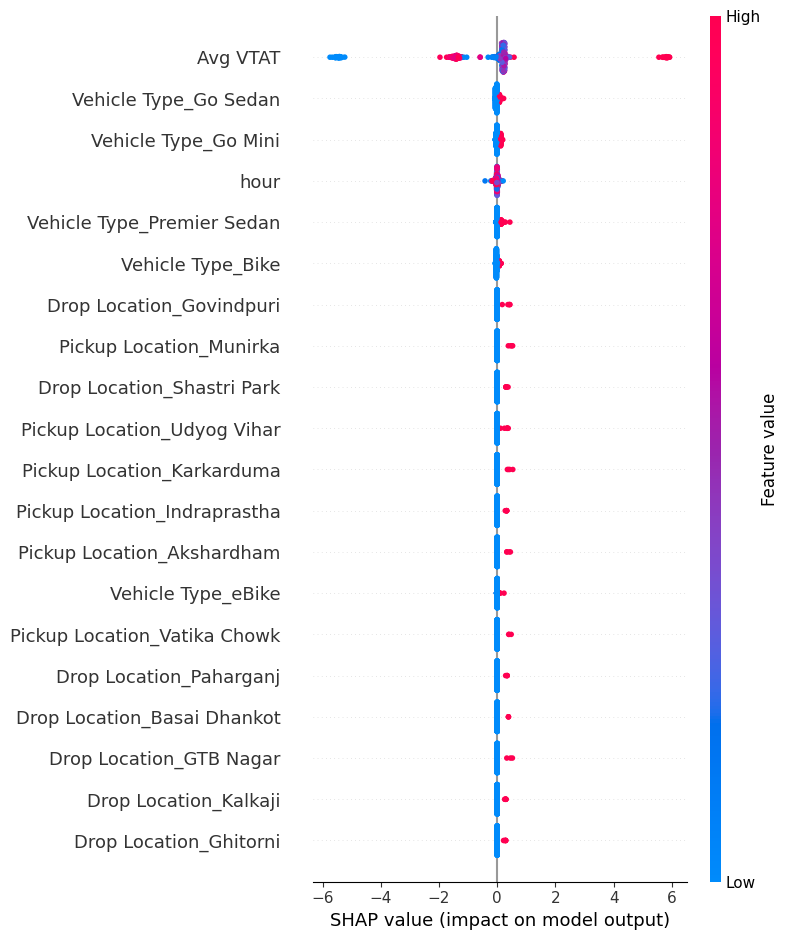

In [ ]:
shap.summary_plot(shap_values, X_sample)

### SHAP Interpretation Results

The SHAP summary plot highlights the most important features influencing ride cancellation predictions.

The most influential feature is Avg VTAT, indicating that longer waiting times significantly increase the likelihood of cancellations. This aligns with real-world expectations, as customers are more likely to cancel when delays are high.

Vehicle type also plays a role in cancellation behavior, suggesting that certain service types may be more prone to cancellations.

Additionally, several pickup and drop locations appear among the top features, indicating that geographical factors may influence cancellation rates.

Overall, the model provides meaningful insights into the operational drivers of ride cancellations, supporting better decision-making.

Data Leakage Consideration
To ensure the validity of the predictive model, potential data leakage was carefully examined.

All features used in the model were reviewed to confirm that they would be available at the time of prediction. Features that could contain information from after the ride outcome were avoided.

Particular attention was given to variables such as waiting time indicators (e.g., Avg VTAT). These were interpreted as historical or estimated values rather than actual realized outcomes.

This step ensures that the model reflects a realistic prediction setting and avoids overly optimistic results.

In [ ]:
# Step 1: remove potentially leaky feature
leaky_features = ['Avg VTAT']

X_train_clean = X_train.drop(columns=leaky_features)
X_test_clean = X_test.drop(columns=leaky_features)

# Step 2: train model again
from xgboost import XGBClassifier

xgb_clean = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_clean.fit(X_train_clean, y_train)

# Step 3: evaluate
from sklearn.metrics import classification_report

y_pred_clean = xgb_clean.predict(X_test_clean)

print("Model WITHOUT Avg VTAT:\n")
print(classification_report(y_test, y_pred_clean))

Model WITHOUT Avg VTAT:

              precision    recall  f1-score   support

           0       0.71      1.00      0.83     18513
           1       0.33      0.00      0.00      7587

    accuracy                           0.71     26100
   macro avg       0.52      0.50      0.42     26100
weighted avg       0.60      0.71      0.59     26100



### Impact of Removing Potential Leakage Feature

After removing the Avg VTAT feature, the model’s ability to detect cancelled rides dropped significantly.

The recall for the cancelled class (class 1) fell to 0.00, meaning that the model failed to identify any cancelled rides.

This suggests that Avg VTAT contains highly predictive information and may act as a key driver of cancellation predictions.

Without this feature, the model lacks sufficient information to distinguish between cancelled and completed rides.

This highlights the importance of operational variables (such as waiting time) in predicting ride cancellations.

### Key Finding

The analysis shows that ride cancellations are not random and are strongly influenced by operational factors, particularly waiting time.

The model performs significantly better when waiting time-related features are included, indicating that delays are a major driver of cancellations.

This provides actionable insights for ride-sharing platforms, suggesting that reducing waiting times could directly decrease cancellation rates.

### Business Recommendations

Based on the findings, the following actions are recommended:

- Reduce driver arrival times to minimize cancellations  
- Provide real-time updates to customers when delays occur  
- Reassign drivers proactively when waiting time exceeds a threshold  
- Monitor high-risk locations with frequent cancellations  

These actions can improve customer satisfaction and reduce lost revenue due to cancellations.

### Conclusion

This project demonstrates that ride cancellations can be predicted using machine learning, but prediction performance depends heavily on the availability of meaningful operational features.

Waiting time (Avg VTAT) was identified as the most important factor influencing cancellations.

Careful handling of potential data leakage is essential to ensure realistic model performance.

Overall, the project provides both predictive insights and practical recommendations for improving ride-sharing operations.